# Fraud Detection & Transaction Monitoring
**Author:** Manzoor Syiemlieh

## Overview
Detecting fraudulent transactions in the Credit Card Fraud dataset (284,807 transactions, 492 fraud — a 0.17% fraud rate). The aim is to catch fraud at the **lowest operational cost**, not the highest accuracy: at 0.17% fraud, a model that flags nothing is 99.8% accurate and catches zero fraud.

Steps: load data → handle class imbalance → split → train three models → evaluate on probability metrics → tune the decision threshold to a business cost → explain with SHAP.

## 1. Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve,
                             precision_score, recall_score, f1_score)
import shap

sns.set_style("whitegrid")

## 2. Load the data
Downloaded `creditcard.csv` from Kaggle (mlg-ulb/creditcardfraud) and put it in a `data` folder. Features `V1`–`V28` are anonymised PCA components; `Time` and `Amount` are raw; `Class` is the target (1 = fraud).

In [4]:
df = pd.read_csv("data/creditcard.csv")
print("Shape:", df.shape)
print("Fraud cases:", df["Class"].sum())
print("Fraud rate:", round(df["Class"].mean() * 100, 3), "%")
df.head()

Shape: (284807, 31)
Fraud cases: 492
Fraud rate: 0.173 %


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Visualisation of class imbalance

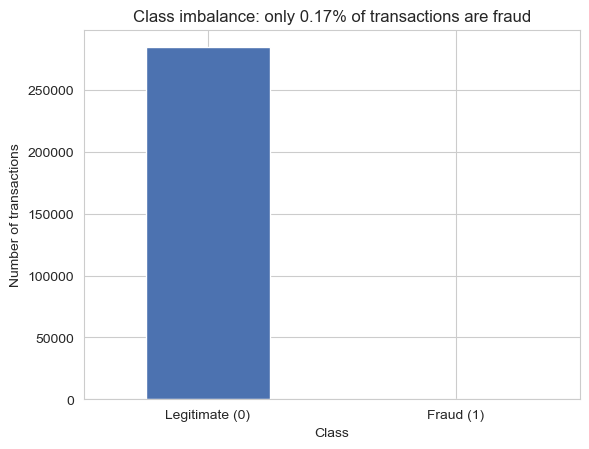

In [5]:
df["Class"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Number of transactions")
plt.title("Class imbalance: only 0.17% of transactions are fraud")
plt.show()

## 3. Define features and target
The `V` features are already PCA-scaled so drop `Time` (just a clock offset) and `Amount` (not on the same scale as the PCA features) and model on `V1`–`V28`. This keeps every feature on one scale and keeps the code simple.

In [6]:
y = df["Class"]
X = df.drop(["Class", "Time", "Amount"], axis=1)
print("Features used:", X.shape[1])

Features used: 28


## 4. Train / Test split
A **stratified** split keeps the same 0.17% fraud rate in both the training and test sets, so the
test set still contains enough fraud to measure.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", x_train.shape, "| fraud in train:", y_train.sum())
print("Test :", x_test.shape,  "| fraud in test :", y_test.sum())

Train: (227845, 28) | fraud in train: 394
Test : (56962, 28) | fraud in test : 98


## 5. Handle the class imbalance
Here I didn't oversample (no SMOTE). Instead telling each model to **weight the rare fraud class more heavily**:
- Logistic Regression and Random Forest: `class_weight="balanced"`.
- XGBoost: `scale_pos_weight = number of legit / number of fraud`.

This makes the models pay attention to fraud instead of ignoring it.

In [8]:
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_legit / n_fraud
print("scale_pos_weight for XGBoost =", round(scale_pos_weight, 1)) #this equals the legit:fraud ratio

scale_pos_weight for XGBoost = 577.3


## 6. Train three models
Training three models so to can compare them: a simple linear baseline, a bagging ensemble, and a boosting ensemble.

In [9]:
# Model 1: Logistic Regression (interpretable baseline)
model_lr = LogisticRegression(class_weight="balanced", max_iter=1000)
model_lr.fit(x_train, y_train)

# Model 2: Random Forest (bagging)
model_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
model_rf.fit(x_train, y_train)

# Model 3: XGBoost (boosting)
model_xgb = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.1,
                          scale_pos_weight=scale_pos_weight,
                          eval_metric="aucpr", random_state=42, n_jobs=-1)
model_xgb.fit(x_train, y_train)

print("All three models trained.")

All three models trained.


## 7. Get predicted probabilities
For each model took the **probability of fraud** (`predict_proba[:, 1]`). Scoring the models on these probabilities and not on hard 0/1 labels because the ranking metrics below need probabilities.

In [10]:
proba_lr  = model_lr.predict_proba(x_test)[:, 1]
proba_rf  = model_rf.predict_proba(x_test)[:, 1]
proba_xgb = model_xgb.predict_proba(x_test)[:, 1]

## 8. Compare the models
**AUPRC (average precision)** is main metric because for a 0.17% fraud problem it is far more honest than ROC-AUC, which looks high no matter what. Both are computed on the probabilities above.

In [11]:
results = []
for name, proba in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf), ("XGBoost", proba_xgb)]:
    results.append({
        "Model": name,
        "ROC_AUC": round(roc_auc_score(y_test, proba), 4),
        "AUPRC":   round(average_precision_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df

,ROC_AUC,AUPRC
Model,,
Logistic Regression,0.9709,0.7092
Random Forest,0.9625,0.8460
XGBoost,0.9739,0.8670


### Detail report for XGBoost (at the default 0.5 threshold)
This shows precision, recall and F1 for the fraud class before tuning the threshold.

In [12]:
y_pred_default = (proba_xgb >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8710    0.8265    0.8482        98

    accuracy                         0.9995     56962
   macro avg     0.9353    0.9132    0.9240     56962
weighted avg     0.9995    0.9995    0.9995     56962



### Precision-Recall curves
For imbalanced fraud data, the precision-recall curve is the right picture: it shows the trade-off
the threshold choice has to make.

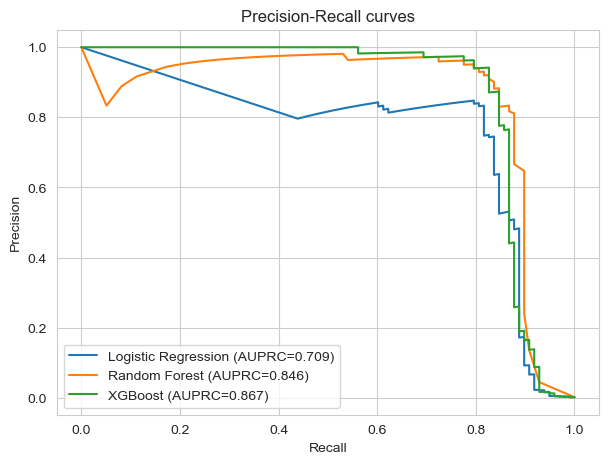

In [13]:
plt.figure(figsize=(7, 5))
for name, proba in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf), ("XGBoost", proba_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=name + " (AUPRC=" + str(round(ap, 3)) + ")")
    
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curves"); plt.legend(); plt.show()

## 9. Threshold optimisation by business cost
The default 0.5 cutoff is rarely best for fraud. Assigned a cost to each outcome and pick the threshold with the **lowest total cost**.

| Outcome | Cost |
|---|---|
| Missed fraud (False Negative) | 100 |
| False alarm (False Positive)  | 10 |
| Correct decisions (TP / TN)   | 1 |

Tried 100 thresholds, compute the total cost at each, and sort ascending — the **top row is the cheapest threshold** (sorting the other way would show the worst one).

In [14]:
cost_fn, cost_fp, cost_tp, cost_tn = 100, 10, 1, 1

thresholds = np.linspace(0, 1, 100)
threshold_list = []
cost_list = []

for t in thresholds:
    y_pred_t = (proba_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
    total_cost = cost_fn*fn + cost_fp*fp + cost_tp*tp + cost_tn*tn
    threshold_list.append(t)
    cost_list.append(total_cost)

cost_df = pd.DataFrame({"Threshold": threshold_list, "Total_Cost": cost_list})
cost_df = cost_df.sort_values("Total_Cost", ascending=True).reset_index(drop=True)
cost_df.head()

,Threshold,Total_Cost
0,0.070707,58501
1,0.060606,58510
2,0.050505,58537
3,0.383838,58555
4,0.292929,58564


### The cost-optimal threshold and its scores

In [15]:
best_threshold = cost_df["Threshold"][0]
y_pred_best = (proba_xgb >= best_threshold).astype(int)

print("Best (cheapest) threshold:", round(best_threshold, 3))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score :", round(f1_score(y_test, y_pred_best), 4))
print()
print(confusion_matrix(y_test, y_pred_best, labels=[0, 1]))

Best (cheapest) threshold: 0.071
Precision: 0.7522
Recall   : 0.8673
F1-score : 0.8057

[[56836    28]
 [   13    85]]


### Cost across all thresholds

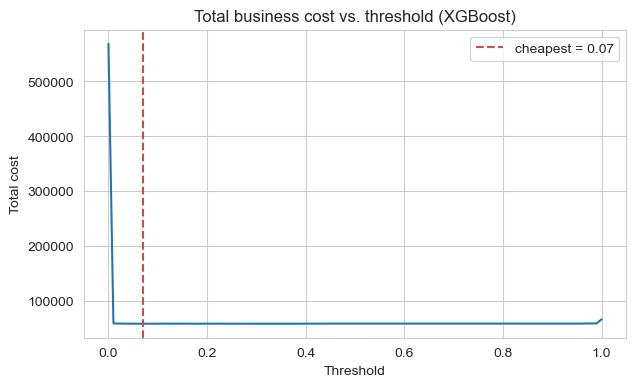

In [16]:
plot_df = cost_df.sort_values("Threshold")
plt.figure(figsize=(7, 4))
plt.plot(plot_df["Threshold"], plot_df["Total_Cost"])
plt.axvline(best_threshold, color="#C44E52", linestyle="--",
            label="cheapest = " + str(round(best_threshold, 2)))
plt.xlabel("Threshold"); plt.ylabel("Total cost")
plt.title("Total business cost vs. threshold (XGBoost)")
plt.legend(); plt.show()

## 10. Explain the model with SHAP
SHAP shows which features push a transaction's score up or down, so a fraud analyst can trust and audit the decision. Expecting a small set of strong features to dominate — matching how real multi-signal fraud behaves.

In [18]:
import os
os.makedirs("reports", exist_ok=True)

sample = x_test.sample(3000, random_state=42)
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False) 
plt.savefig("reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved reports/shap_summary.png")

Saved reports/shap_summary.png


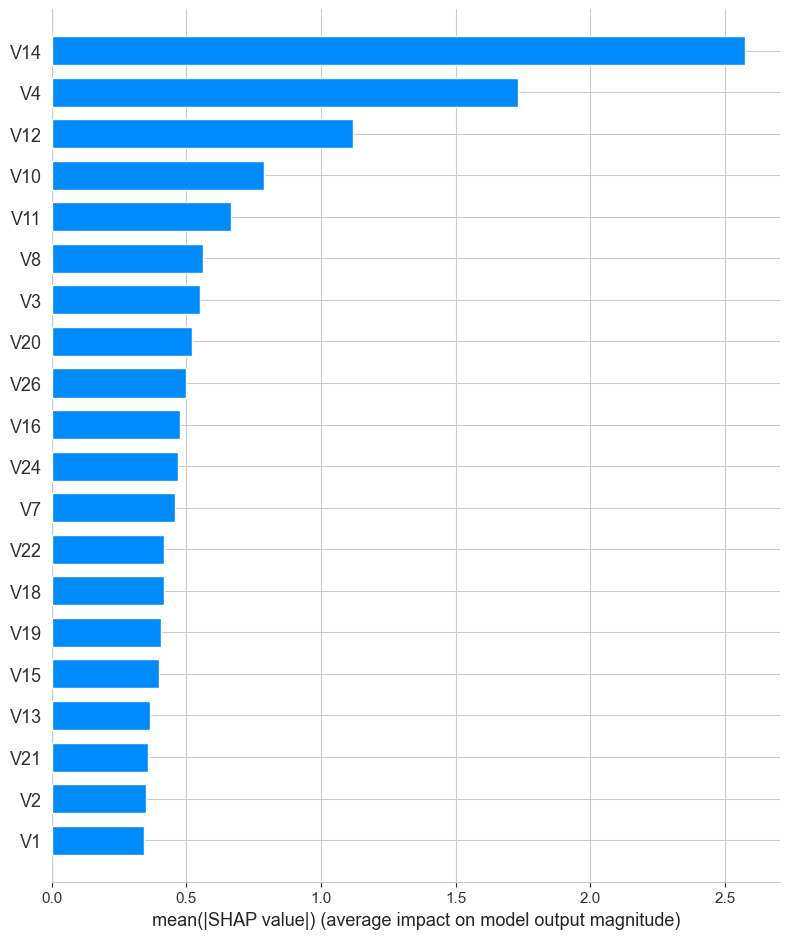

In [19]:
shap.summary_plot(shap_values, sample, plot_type="bar")

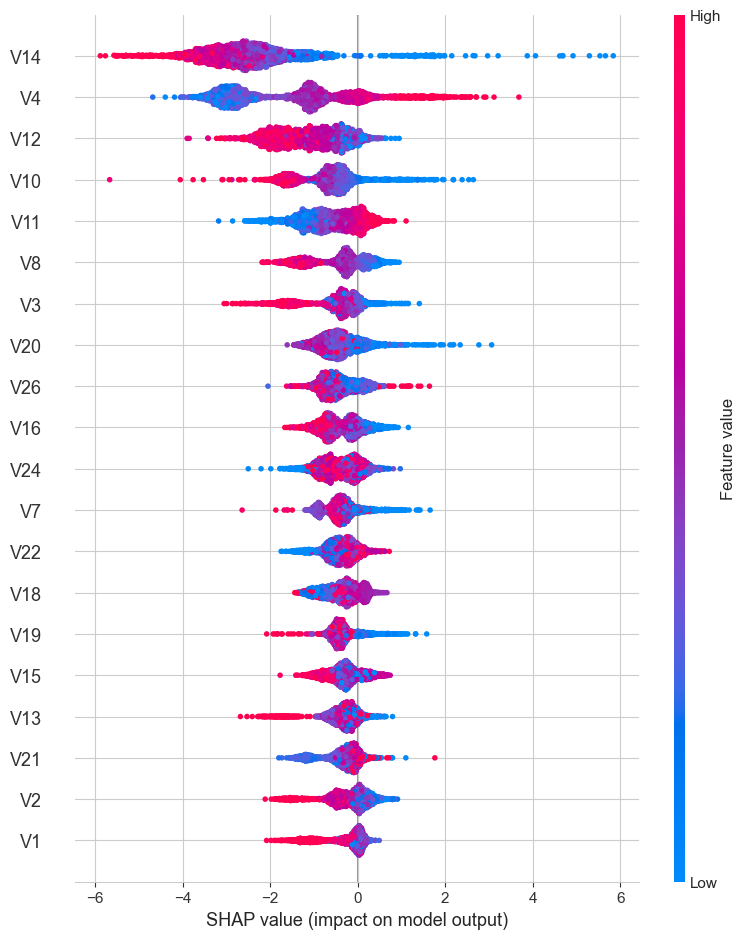

In [20]:
shap.summary_plot(shap_values, sample)

In [21]:
import os, json
os.makedirs("model", exist_ok=True)
model_xgb.save_model("model/fraud_xgb.json")          #XGBoost native format version-portable
json.dump(list(X.columns), open("model/feature_columns.json", "w"))  #locks the 28-column order
print("Saved model/fraud_xgb.json and feature_columns.json")

Saved model/fraud_xgb.json and feature_columns.json


In [22]:
sample_out = x_test.copy()
sample_out["Class"] = y_test.values
sample_out = pd.concat([
    sample_out[sample_out["Class"] == 1].sample(20, random_state=42),
    sample_out[sample_out["Class"] == 0].sample(180, random_state=42),
]).sample(frac=1, random_state=42)
sample_out.to_csv("data/sample_transactions.csv", index=False)
print("Saved", sample_out.shape, "to data/sample_transactions.csv")

Saved (200, 29) to data/sample_transactions.csv


## 11. Conclusion
- **XGBoost** gives the best AUPRC (see the comparison table in section 8).
- **Tuning the threshold** to business cost lowers total operational cost versus the default 0.5 cutoff (section 9).
- **SHAP** confirms the model relies on a small set of strong signal features, consistent with real fraud typologies (velocity abuse, behavioural anomalies, account-takeover patterns).